# Regional panel with AlphaGenome tracks

> **Under development** — not published in docs. Requires `gwaslab` from source and [gwaslab-alphagenome](https://github.com/Cloufield/gwaslab-alphagenome) for live API cells.

Stack **AlphaGenome** predicted tracks with a GWAS **region** panel using `gl.Panel` and `gl.plot_panels`.

- AlphaGenome fetching: [gwaslab-alphagenome](https://github.com/Cloufield/gwaslab-alphagenome)
- AlphaGenome human predictions require **hg38** coordinates
- Live API: `pip install gwaslab-alphagenome` and `ALPHA_GENOME_API_KEY`

## Load GWASLab

In [1]:
import sys
sys.path.insert(0, "/home/yunye/work/gwaslab/src")
import gwaslab as gl

In [2]:
gl.show_version()

2026/06/10 17:22:02 GWASLab v4.1.9 https://cloufield.github.io/gwaslab/
2026/06/10 17:22:02 (C) 2022-2026, Yunye He, Kamatani Lab, GPL-3.0 license, gwaslab@gmail.com
2026/06/10 17:22:02 Python version: 3.12.0 | packaged by conda-forge | (main, Oct  3 2023, 08:43:22) [GCC 12.3.0]


## Load sample sumstats (chr7, hg19)

In [3]:
mysumstats = gl.Sumstats("../../0_sample_data/t2d_bbj.txt.gz",
             snpid="SNP",
             chrom="CHR",
             pos="POS",
             ea="ALT",
             nea="REF",
             neaf="Frq",
             beta="BETA",
             se="SE",
             p="P",
             direction="Dir",
             build="19",
             chrom_pat="7",
             n="N")
mysumstats.basic_check(verbose=False)

2026/06/10 17:22:02 GWASLab v4.1.9 https://cloufield.github.io/gwaslab/
2026/06/10 17:22:02 (C) 2022-2026, Yunye He, Kamatani Lab, GPL-3.0 license, gwaslab@gmail.com
2026/06/10 17:22:02 Python version: 3.12.0 | packaged by conda-forge | (main, Oct  3 2023, 08:43:22) [GCC 12.3.0]
2026/06/10 17:22:02  -Top 3 inferred source formats:
2026/06/10 17:22:02    1. pheweb [DETECTED] (score: 23.608) | 2. gwaslab (score: 20.789) | 3. ldsc (score: 18.116)
2026/06/10 17:22:02 Start to initialize gl.Sumstats from file :../../0_sample_data/t2d_bbj.txt.gz
2026/06/10 17:22:02  -Columns used to filter variants: CHR
2026/06/10 17:22:02  -Loading only variants on chromosome with pattern : 7 ...
2026/06/10 17:22:15  -Loaded 707780 variants on chromosome with pattern :7 ...
2026/06/10 17:22:15  -Reading columns          : ALT,REF,BETA,SE,SNP,N,Frq,Dir,CHR,POS,P
2026/06/10 17:22:15  -Renaming columns to      : EA,NEA,BETA,SE,SNPID,N,EAF,DIRECTION,CHR,POS,P
2026/06/10 17:22:15  -Current Dataframe shape : 7077

,SNPID,CHR,POS,EA,NEA,STATUS,EAF,BETA,SE,P,DIRECTION,N
0,7:40386_A_G,7,40386,G,A,1960099,0.3325,0.0070,0.0167,0.6748,++-+,191764
1,7:40845_C_T,7,40845,C,T,1960099,0.6646,-0.0076,0.0167,0.6490,--+-,191764
2,7:42289_G_A,7,42289,G,A,1960099,0.9559,0.0082,0.0290,0.7765,+-+-,191764
3,7:43050_A_C,7,43050,C,A,1960099,0.0500,-0.0092,0.0282,0.7451,-+--,191764
4,7:44444_T_C,7,44444,C,T,1960099,0.0483,-0.0086,0.0276,0.7548,-+--,191764
...,...,...,...,...,...,...,...,...,...,...,...,...
707775,7:159122935_A_C,7,159122935,C,A,1960099,0.2773,-0.0023,0.0111,0.8376,++--,191764
707776,7:159125187_G_C,7,159125187,G,C,1960099,0.2430,-0.0023,0.0111,0.8384,++--,191764
707777,7:159126346_A_G,7,159126346,G,A,1960099,0.0049,-0.0246,0.0779,0.7524,+-+-,191764
707778,7:159126810_G_A,7,159126810,G,A,1960099,0.9951,0.0262,0.0784,0.7386,-+-+,191764


## Live AlphaGenome fetch (hg38)

1. Liftover and harmonize sumstats to **hg38**
2. Define an hg38 `region` tuple `(chr, start, end)`
3. Pass `ag_spec=glag.Spec(...)` on `gl.Panel`; `plot_panels` calls `glag.extract_batch()`

/home/yunye/anaconda3/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026/06/10 17:22:21 Filtered out args for `plot_region`: highlight
2026/06/10 17:22:21 Start to create stacked panels plot...
2026/06/10 17:22:21  -Number of panels: 3
2026/06/10 17:22:21  -Materializing 2 AlphaGenome panel(s) via extract_batch...
2026/06/10 17:22:23  -Total subplot count: 7 (including multi-axis panels)
2026/06/10 17:22:23 Configured plot style for plot_panels:None
2026/06/10 17:22:23  -Using default height ratios: ['4.00', '2.00', '2.00', '2.00', '2.00', '2.00', '2.00']
2026/06/10 17:22:23  -Auto-adjusted figsize: (10.0, 16.0) based on 3 panels (7 subplots)
2026/06/10 17:22:23  -Creating figure with 7 subplots...
2026/06/10 17:22:23  -Plotting panels...
2026/06/10 17:22:23   -Panel 1/3: type='region'
2026/06/10 17:22:23 Configured plot style for plot_mqq:r
2026/06/10 17:22:23 Starting Region plot creation (Version v4.1.9)
2026/06/10 17:22:23  -Genomic coordinates are based on GRCh38/hg38...
2026/06/10 17:22:23  - Genomic coordinates version: 38 ...
2026/06/10 17:22:2

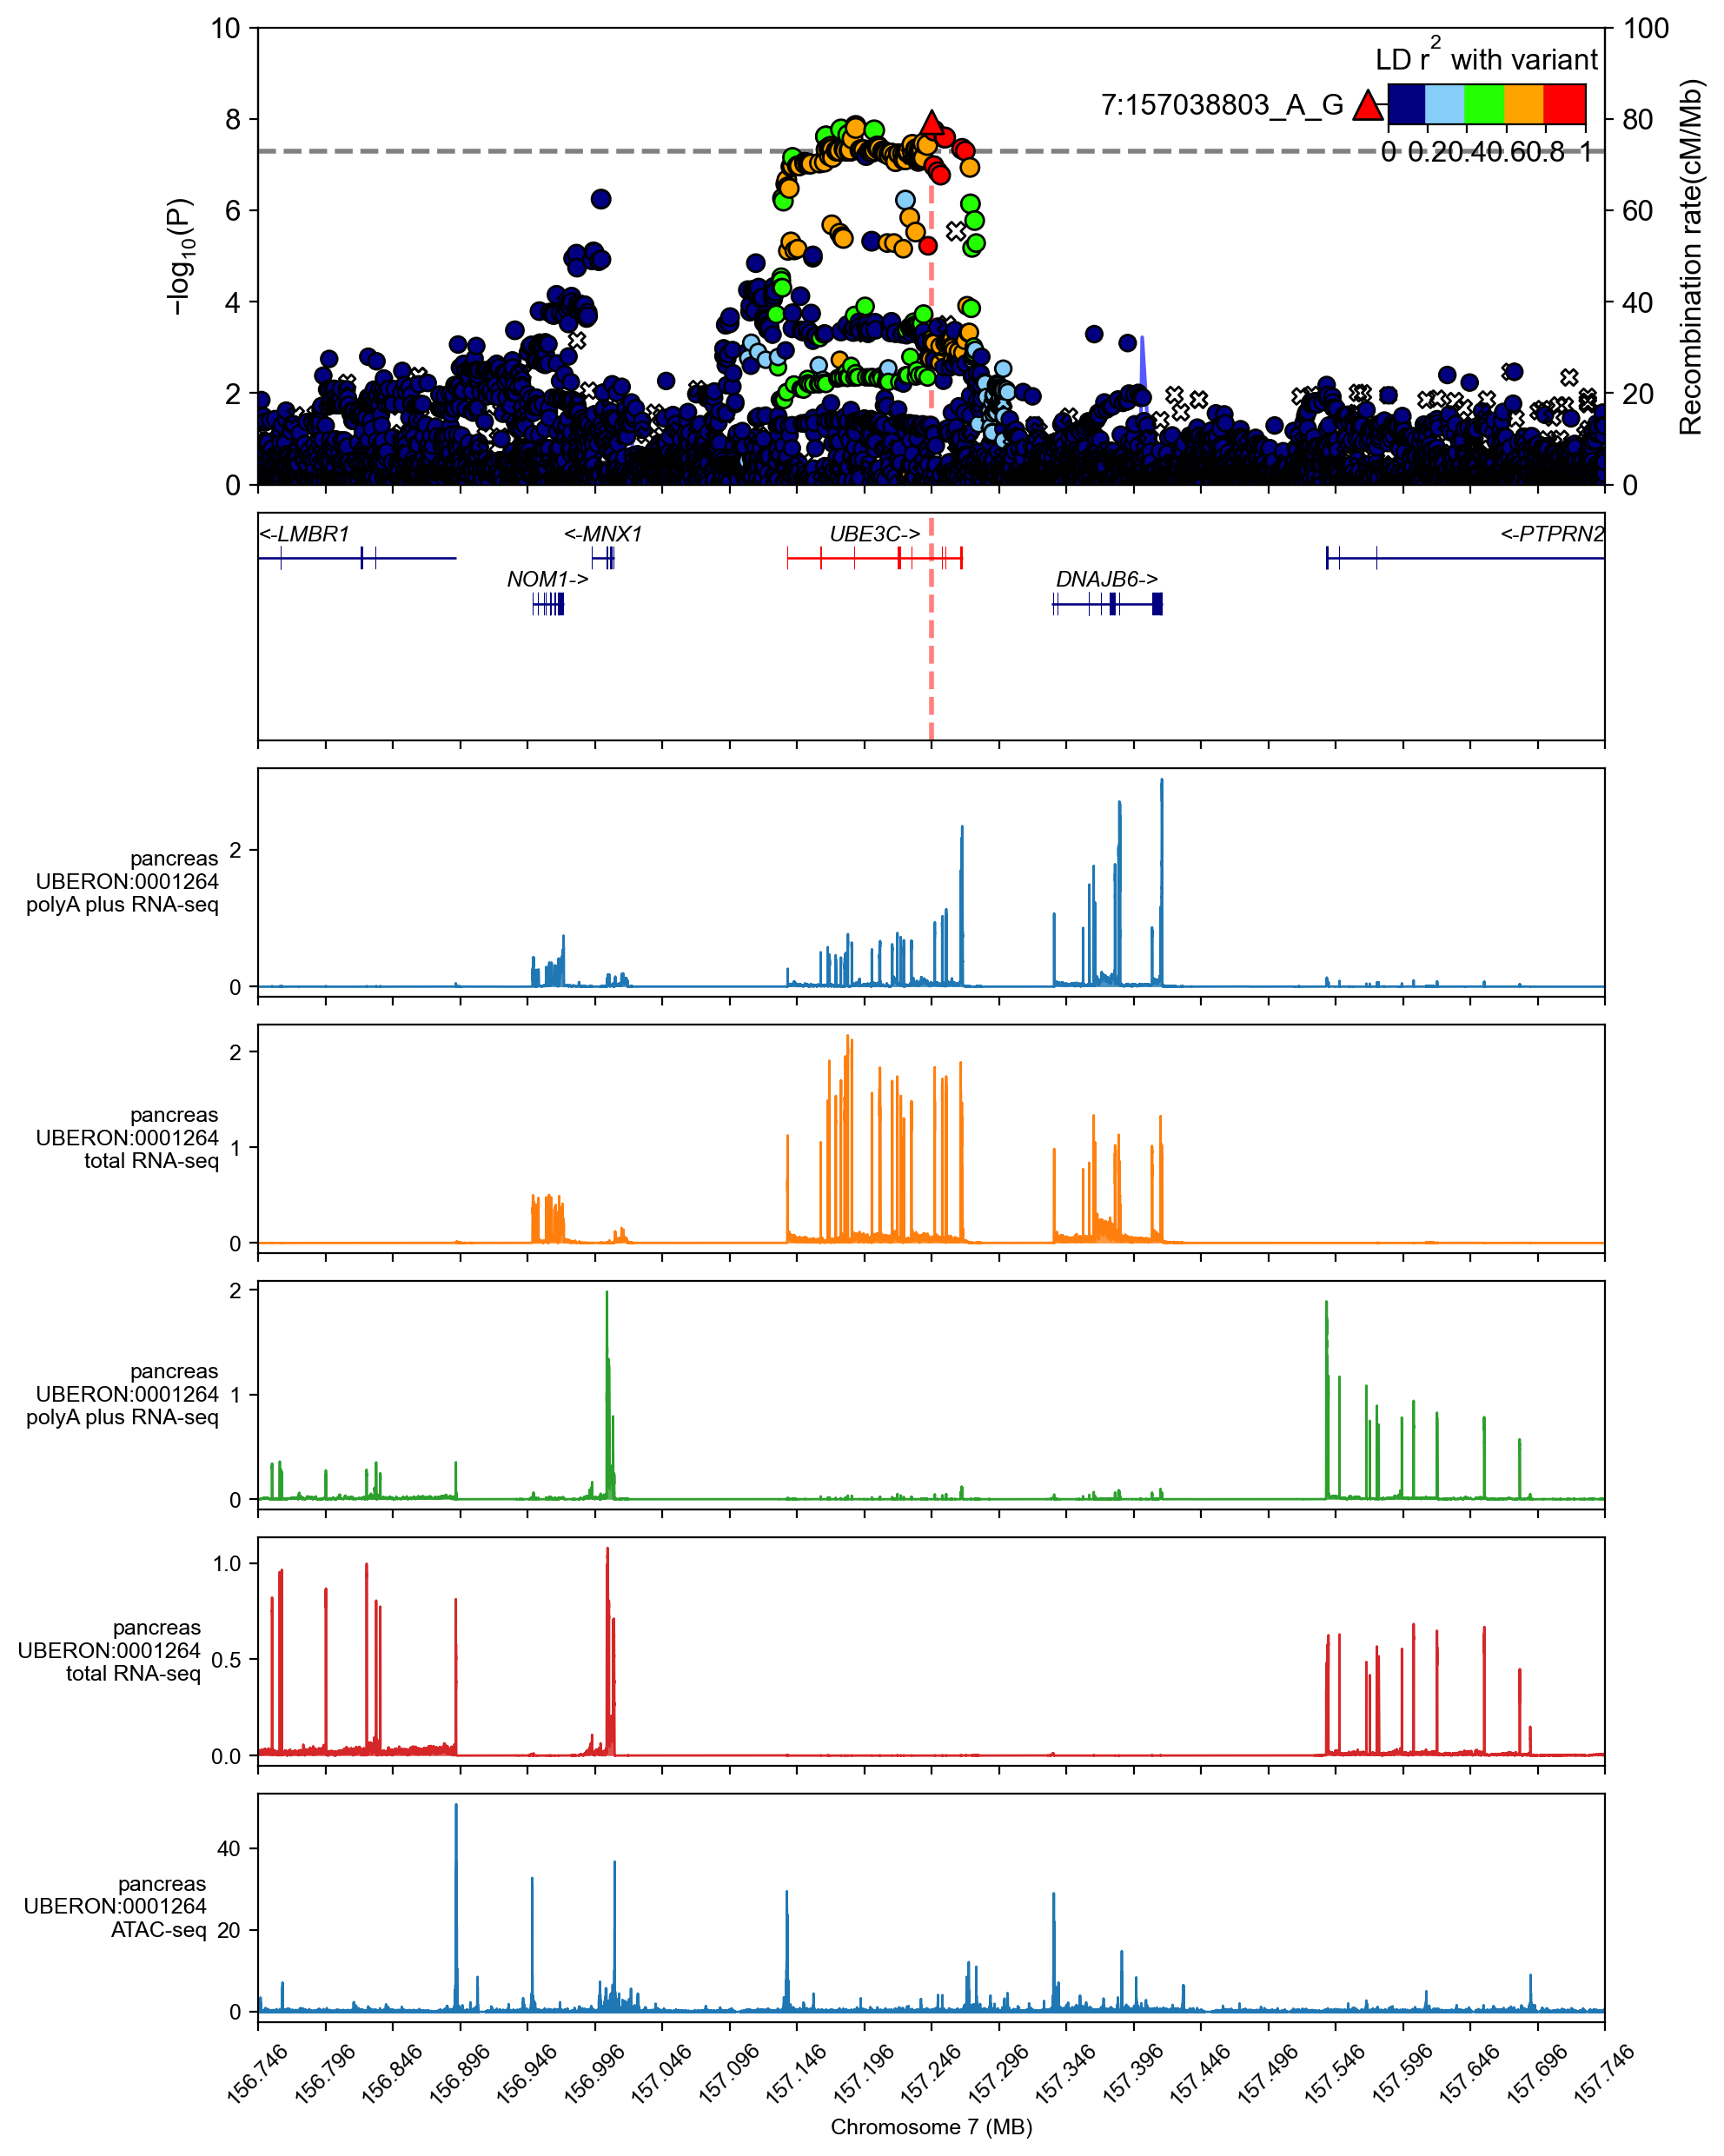

In [4]:
# Requires: pip install gwaslab-alphagenome
# export ALPHA_GENOME_API_KEY=your_key

import gwaslab_alphagenome as glag

mysumstats.liftover(from_build="19", to_build="38", verbose=False)

region38 = (7, 156746109, 157746109)

panels_live = [

    mysumstats.Panel(
        "region",
        region=region38,
        vcf_path=gl.get_path("1kg_eas_hg38"),
        build="38",
    ),
        gl.Panel(
        "ag_tracks",
        region=region38,
        build="38",
        ag_spec=glag.Spec("RNA_SEQ", ontology_terms=["UBERON:0001264"]),
        filled=True,
    ),
    gl.Panel(
        "ag_tracks",
        region=region38,
        build="38",
        ag_spec=glag.Spec("ATAC", ontology_terms=["UBERON:0001264"]),
    ),
]

fig, axes = gl.plot_panels(
    panels_live,
    region=region38,
    #titles=["RNA-seq", "ATAC", "GWAS regional plot"],
    save="region_panel_alphagenome_live.png",
)

### Variant-linked overlay (optional)

Link a lead SNP to LD coloring and REF/ALT track overlays:

2026/06/10 17:22:43 Filtered out args for `plot_region`: highlight
2026/06/10 17:22:43 Start to create stacked panels plot...
2026/06/10 17:22:43  -Number of panels: 2
2026/06/10 17:22:43  -Materializing 1 AlphaGenome panel(s) via extract_batch...
2026/06/10 17:22:46  -Total subplot count: 10 (including multi-axis panels)
2026/06/10 17:22:46 Configured plot style for plot_panels:None
2026/06/10 17:22:46  -Using default height ratios: ['4.00', '2.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00']
2026/06/10 17:22:46  -Auto-adjusted figsize: (10.0, 14.0) based on 2 panels (10 subplots)
2026/06/10 17:22:46  -Creating figure with 10 subplots...
2026/06/10 17:22:46  -Plotting panels...
2026/06/10 17:22:46   -Panel 1/2: type='region'
2026/06/10 17:22:46 Configured plot style for plot_mqq:r
2026/06/10 17:22:46 Starting Region plot creation (Version v4.1.9)
2026/06/10 17:22:46  -Genomic coordinates are based on GRCh38/hg38...
2026/06/10 17:22:46  - Genomic coordinates version

(<Figure size 2000x2800 with 12 Axes>,
 array([<Axes: title={'left': 'REF vs ALT RNA-seq'}, ylabel='$\\mathregular{-log_{10}(P)}$'>,
        <Axes: >,
        <Axes: title={'left': 'GWAS regional plot'}, ylabel='REF\nlung\nUBERON:0002048\npolyA plus RNA-seq'>,
        <Axes: ylabel='ALT\nlung\nUBERON:0002048\npolyA plus RNA-seq'>,
        <Axes: ylabel='REF\nlung\nUBERON:0002048\ntotal RNA-seq'>,
        <Axes: ylabel='ALT\nlung\nUBERON:0002048\ntotal RNA-seq'>,
        <Axes: ylabel='REF\nlung\nUBERON:0002048\npolyA plus RNA-seq'>,
        <Axes: ylabel='ALT\nlung\nUBERON:0002048\npolyA plus RNA-seq'>,
        <Axes: ylabel='REF\nlung\nUBERON:0002048\ntotal RNA-seq'>,
        <Axes: xlabel='Chromosome 7 (MB)', ylabel='ALT\nlung\nUBERON:0002048\ntotal RNA-seq'>],
       dtype=object))

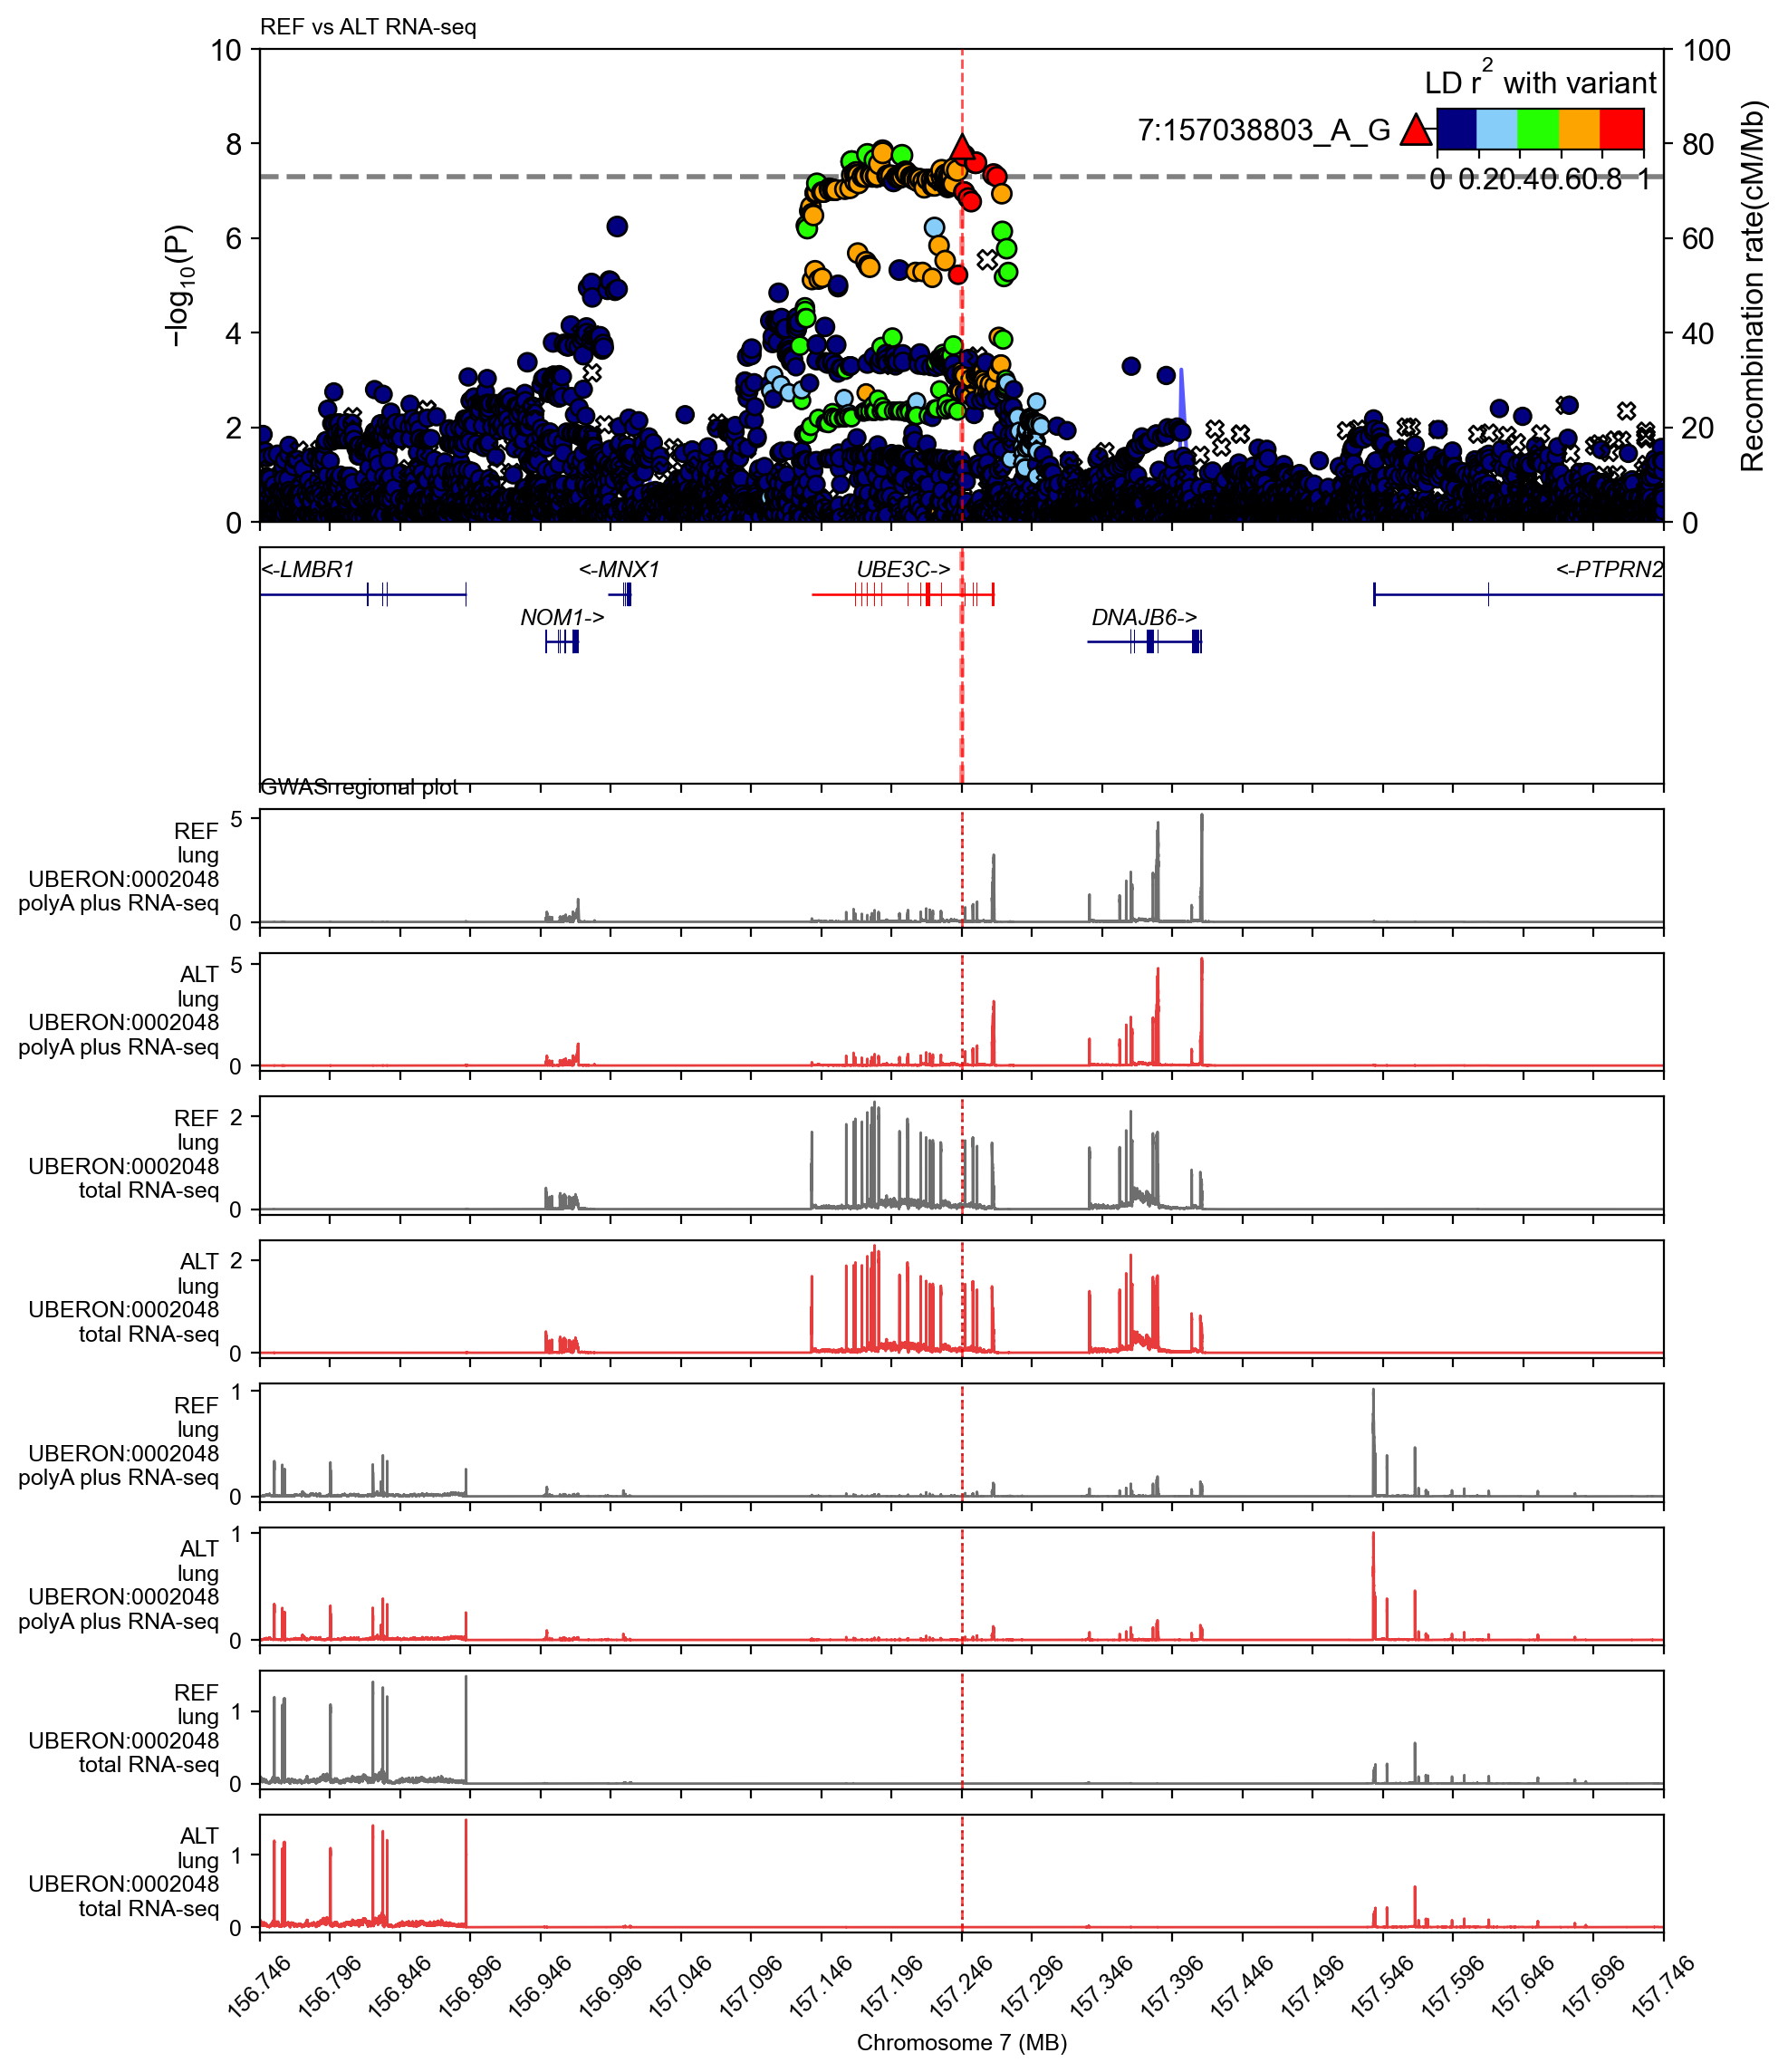

In [5]:
ctx = glag.resolve_variant(mysumstats.data, region_ref="7:157038803_A_G", build="38")

overlay_panels = [

    mysumstats.Panel(
        "region",
        region=region38,
        region_ref=ctx.region_ref,
        vcf_path=gl.get_path("1kg_eas_hg38"),
        build="38",
    ),
    gl.Panel(
        "ag_overlay",
        region=region38,
        build="38",
        variant_context=ctx,
        ag_spec=glag.Spec("RNA_SEQ", mode="overlay", ontology_terms=["UBERON:0002048"]),
    ),
]

gl.plot_panels(
    overlay_panels,
    region=region38,
    variant_positions=[ctx.pos],
    titles=["REF vs ALT RNA-seq", "GWAS regional plot"],
    save="region_panel_alphagenome_overlay.png",
)